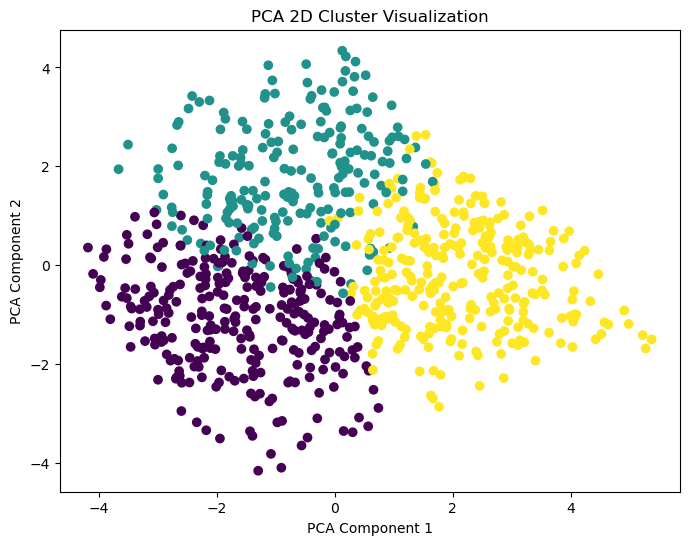

Explained Variance Ratio (2D): [0.44978169 0.27159792]
Total Variance (2D): 0.7213796111306134


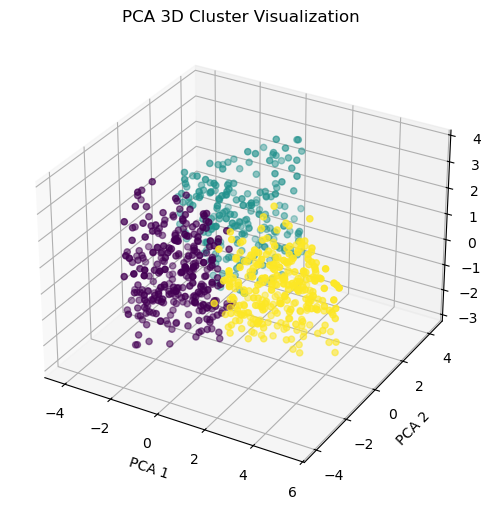

Explained Variance Ratio (3D): [0.44978169 0.27159792 0.22812579]
Total Variance (3D): 0.9495054015685123


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


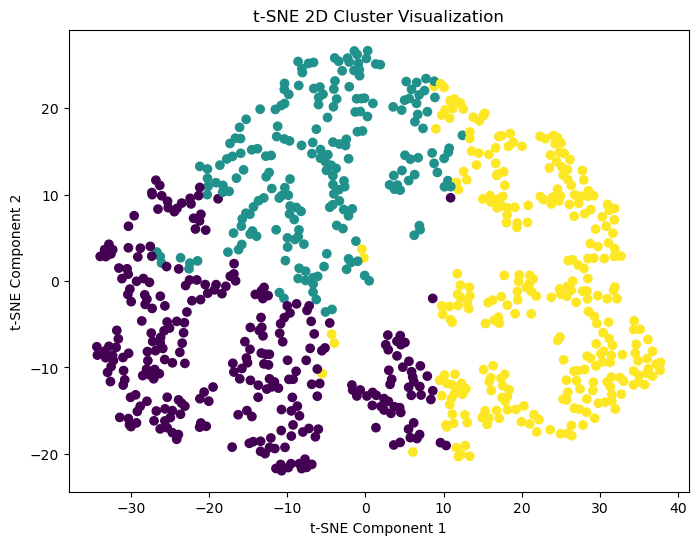

In [1]:
# ==============================
# 1. Import Required Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("../data/online_retail_customer_churn.csv")

# ==============================
# 3. Basic Preprocessing
# ==============================

# Remove missing values
df = df.dropna()

# Select only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# ==============================
# 4. Feature Scaling
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# ==============================
# 5. Apply KMeans Clustering
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ==============================
# 6. PCA - 2D
# ==============================
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=clusters)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA 2D Cluster Visualization")
plt.show()

print("Explained Variance Ratio (2D):",
      pca_2d.explained_variance_ratio_)
print("Total Variance (2D):",
      sum(pca_2d.explained_variance_ratio_))

# ==============================
# 7. PCA - 3D
# ==============================
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:,0],
           X_pca_3d[:,1],
           X_pca_3d[:,2],
           c=clusters)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("PCA 3D Cluster Visualization")
plt.show()

print("Explained Variance Ratio (3D):",
      pca_3d.explained_variance_ratio_)
print("Total Variance (3D):",
      sum(pca_3d.explained_variance_ratio_))


tsne = TSNE(n_components=2,
            random_state=42,
            perplexity=30,
            n_iter=1000)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE 2D Cluster Visualization")
plt.show()
